In [ ]:
! pip install numpy torchvision matplotlib torch scikit-learn imagecorruptions kagglehub tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.5 MB/s eta 0:00:00


In [ ]:
from PIL import Image
import os
import kagglehub
import numpy as np
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
import pandas as pd
import matplotlib.patches as patches
from IPython.display import display
from google.colab.patches import cv2_imshow
import cv2

warnings.filterwarnings("ignore")

In [ ]:
# Download latest version (need to run only once)
path = kagglehub.dataset_download("nguyngiabol/colorful-fashion-dataset-for-object-detection")

print("Path to dataset files:", path)

100%|██████████| 104M/104M [00:00<00:00, 146MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nguyngiabol/colorful-fashion-dataset-for-object-detection/versions/1


In [ ]:
%ls /root/.cache/kagglehub/datasets/nguyngiabol/colorful-fashion-dataset-for-object-detection/versions/1/colorful_fashion_dataset_for_object_detection/ImageSets/Main

test.txt  trainval.txt


In [ ]:
base_path = os.path.join(path, "colorful_fashion_dataset_for_object_detection")


In [ ]:
xml_path = os.path.join(base_path, "Annotations")
img_path = os.path.join(base_path, "JPEGImages")

In [ ]:
trainval_path = os.path.join(base_path, "ImageSets/Main/trainval.txt")
test_path = os.path.join(base_path, "ImageSets/Main/test.txt")
with open(trainval_path, "r") as f:
    trainval_list = f.read().splitlines()
with open(test_path, "r") as f:
    test_list = f.read().splitlines()

In [ ]:
trainval_list

['168468',
 '20751',
 '184291',
 '63239',
 '110606',
 '31187',
 '103194',
 '137927',
 '89286',
 '46319',
 '62403',
 '53324',
 '30169',
 '185536',
 '98155',
 '175092',
 '121359',
 '50761',
 '184951',
 '81298',
 '133345',
 '47897',
 '13689',
 '120376',
 '185145',
 '88148',
 '138332',
 '124731',
 '64263',
 '102551',
 '123954',
 '83626',
 '100034',
 '13302',
 '159249',
 '110686',
 '62639',
 '53060',
 '26107',
 '115148',
 '186905',
 '17856',
 '104798',
 '14058',
 '177993',
 '30429',
 '185196',
 '23001',
 '110739',
 '191287',
 '103419',
 '165166',
 '144894',
 '87026',
 '185830',
 '73507',
 '87406',
 '177810',
 '55928',
 '84072',
 '11674',
 '27992',
 '47978',
 '105494',
 '81865',
 '12175',
 '164716',
 '88622',
 '151175',
 '2061',
 '39123',
 '41142',
 '13722',
 '90104',
 '185714',
 '92267',
 '1388',
 '88380',
 '181527',
 '187362',
 '35921',
 '80692',
 '444',
 '52202',
 '176907',
 '171839',
 '62605',
 '130366',
 '47502',
 '173552',
 '82309',
 '136647',
 '42251',
 '2499',
 '15707',
 '112639',
 '

In [ ]:
def extract_xml(path):
    CLASS_MAP = {
        "sunglass": 0,
        "hat": 1,
        "jacket": 2,
        "shirt": 3,
        "pants": 4,
        "shorts": 5,
        "skirt": 6,
        "dress": 7,
        "bag": 8,
        "shoe": 9
    }
    tree = ET.parse(path)
    root = tree.getroot()
    all_objs = []
    for object in root.findall("object"):
        name = object.find("name").text
        box = object.find("bndbox")
        xmin = round(float(box.find("xmin").text))
        xmax = round(float(box.find("xmax").text))
        ymin = round(float(box.find("ymin").text))
        ymax = round(float(box.find("ymax").text))
        w = xmax - xmin
        h = ymax - ymin
        cx = (xmax + xmin) / 2
        cy = (ymin + ymax) / 2
        id = CLASS_MAP[name]
        all_objs.append([id, cx, cy, w, h])
    return np.array(all_objs)

In [ ]:
# Function to visualize image with bounding boxes
def plot_bounding(img_path, bboxes):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    for bbox in bboxes:
        x0 = bbox[1] - bbox[3] / 2
        x1 = bbox[1] + bbox[3] / 2
        y0 = bbox[2] - bbox[4] / 2
        y1 = bbox[2] + bbox[4] / 2
        draw.rectangle([x0, y0, x1, y1], outline="red")
    display(img)

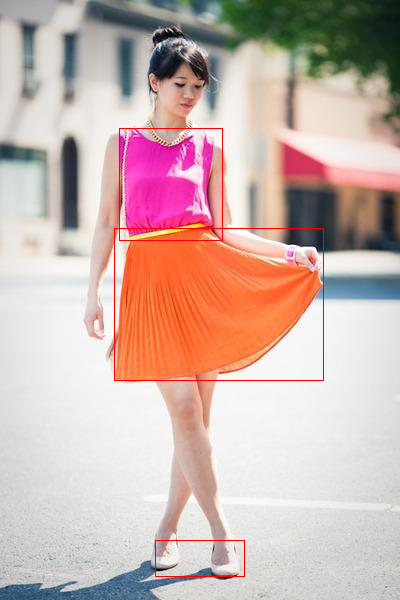

In [ ]:
for i in trainval_list[:1]:
    # print(train_ids[1])
    xml = i + ".xml"
    jpg_path = i + ".jpg"
    # print(xml)
    # print(jpg_path)
    # print(bboxes)
    bboxes = extract_xml(os.path.join(xml_path, xml))
    plot_bounding(os.path.join(img_path, jpg_path), bboxes)

In [ ]:
# for each id in list:
  # load jpg image
  # extract bounding boxes
  # call another function that for each bounding box in the list of boxes:
    # saves the label of the bounding box to a directory
    # gets the actual x0, x1, y0, y2 coordinates
    # crops and pads, resizes the image and saves it to a directory

In [ ]:
def clahe_bgr(img):
  lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
  lab_planes = list(cv2.split(lab))
  clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8, 8))
  lab_planes[0] = clahe.apply(lab_planes[0])
  lab = cv2.merge(lab_planes)
  bgr2 = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
  return bgr2

In [ ]:
def clahe_grayscale(img):
  clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8, 8))
  img = clahe.apply(img)
  return img

In [ ]:
def add_padding(cropped, height, width):
  diff = np.abs(height - width)
  p1 = diff // 2
  p2 = diff - p1
  if height > width:
    padded = cv2.copyMakeBorder(cropped, 0, 0, p1, p2, cv2.BORDER_CONSTANT, value=[0, 0, 0])
  else:
    padded = cv2.copyMakeBorder(cropped, p1, p2, 0, 0, cv2.BORDER_CONSTANT, value=[0, 0, 0])
  return padded


In [ ]:
def save_images(img, bbox_list, base_img_id, split):
  counter = 0
  for bbox in bbox_list:
    counter += 1
    label = bbox[0]
    dir = f'/content/crops/{split}/class_{label}'
    if not os.path.exists(dir):
      os.makedirs(dir)
    x0 = int(bbox[1] - bbox[3] / 2)
    x1 = int(bbox[1] + bbox[3] / 2)
    y0 = int(bbox[2] - bbox[4] / 2)
    y1 = int(bbox[2] + bbox[4] / 2)
    height = y1 - y0
    width = x1 - x0
    cropped = img[y0:y1, x0:x1]
    cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    normalized = clahe_grayscale(cropped)
    padded = add_padding(normalized, height, width)
    final = cv2.resize(padded, (128, 128))
    cv2.imwrite(f'{dir}/{base_img_id}_{counter}.jpg', final)


In [ ]:
def preprocess_images(list_of_ids, split):
  for i in list_of_ids:
    xml = i + ".xml"
    jpg_path = i + ".jpg"
    bboxes = extract_xml(os.path.join(xml_path, xml))
    img = cv2.imread(os.path.join(img_path, jpg_path))
    save_images(img, bboxes, i, split)


In [ ]:
preprocess_images(trainval_list, "train")

In [ ]:
preprocess_images(test_list, "test")

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/agents_project2/'

if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"Created directory: {save_path}")

Mounted at /content/drive
Created directory: /content/drive/MyDrive/agents_project2/


In [ ]:
!zip -r clothing_crops.zip /content/crops/

Streaming output truncated to the last 5000 lines.
  adding: content/crops/train/class_3.0/106831_2.jpg (deflated 0%)
  adding: content/crops/train/class_3.0/184951_1.jpg (deflated 1%)
  adding: content/crops/train/class_3.0/189988_2.jpg (deflated 0%)
  adding: content/crops/train/class_3.0/20101_2.jpg (deflated 0%)
  adding: content/crops/train/class_3.0/88450_1.jpg (deflated 0%)
  adding: content/crops/train/class_3.0/27328_1.jpg (deflated 1%)
  adding: content/crops/train/class_3.0/12910_2.jpg (deflated 1%)
  adding: content/crops/train/class_3.0/104589_2.jpg (deflated 0%)
  adding: content/crops/train/class_3.0/55977_1.jpg (deflated 0%)
  adding: content/crops/train/class_3.0/78332_1.jpg (deflated 0%)
  adding: content/crops/train/class_3.0/189228_2.jpg (deflated 0%)
  adding: content/crops/train/class_3.0/110171_1.jpg (deflated 1%)
  adding: content/crops/train/class_3.0/96428_1.jpg (deflated 0%)
  adding: content/crops/train/class_3.0/185428_2.jpg (deflated 0%)
  adding: content/

In [ ]:
!cp clothing_crops.zip /content/drive/MyDrive/agents_project2/